### **For this assignment the only permitted libraries to use are Numpy, Scipy, MatplotLib and Pandas! Use of generative AI is not allowed.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

## Data loading

In [2]:
# Unzip train_data_2026.npy, test_data_2026.npy, val_data_2026.npy
# Load the data
train_data = np.load('all_data/train_data_2026.npy')
test_data = np.load('all_data/test_data_2026.npy')
val_data = np.load('all_data/val_data_2026.npy')

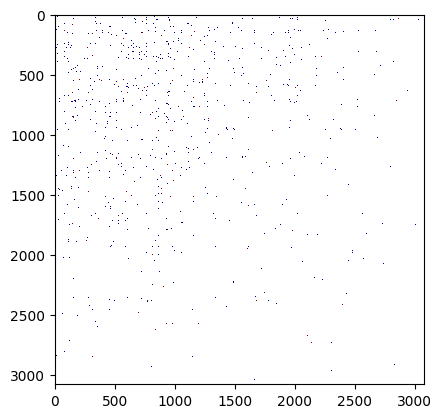

In [3]:
def plot_data(data, begin_id=-1, end_id=-1):
    if begin_id == -1: begin_id = 0
    if end_id == -1: end_id = data.shape[0]

    cmap = cm.jet
    cmap.set_bad('WHITE', 1.)

    # Slicing the data
    new_data = data[begin_id:end_id, begin_id:end_id]
    masked_array_train = np.ma.array(new_data, mask=np.isnan(new_data))

    # 'extent' defines the (left, right, bottom, top) limits
    plt.imshow(masked_array_train, 
               interpolation='nearest', 
               cmap=cmap, 
               extent=[begin_id, end_id, end_id, begin_id]) # Note: top/bottom swapped to keep matrix orientation
    
    plt.pause(0.1)

plot_data(train_data)

**Familiarization questions**

1.	What properties of the data do you think are important for your pipeline design? Think of the data sparsity and distribution of labels.

2.	What are some sources of sparsity in the data?

3.	Do you see different types of people (in terms of both which id pairs are present and what they liked/didn’t like)?

### Question 1: **What properties of the data do you think are important for your pipeline design? Think of the data sparsity and distribution of labels.**

In the above graph, the **nan** values are marked as white pixels, so we can already notice that our training data is mostly empty. Let's look even close.

Let's also look at a percentage over the entire training data matrix.

In [4]:
def calculate_nan_percentage(data):
    total = data.shape[0] * data.shape[1]
    nans = np.isnan(data).sum().item()

    return nans / total * 100

calculate_nan_percentage(train_data)

99.43477331560074

99.4% of training data is unknown! Let's also look at the validity data and the train data.

In [5]:

print(f"Validity nan percentage: {calculate_nan_percentage(val_data)}")
print(f"Test nan percentage: {calculate_nan_percentage(test_data)}")

Validity nan percentage: 99.88357557876309
Test nan percentage: 99.90099152702189


As we can see, data is sparser and sparser for validity and test data. What else should we think about? Let's look at the like and dislike percentage for all 3 types of data, ignoring the nan values.

In [6]:
def calculate_like_dislike_ratio(data):
    likes = (data == 1).sum().item()
    dislikes = (data == 0).sum().item()

    return likes / (likes + dislikes) * 100

def calculate_dislike_like_ratio(data):
    likes = (data == 1).sum().item()
    dislikes = (data == 0).sum().item()

    return dislikes / (likes + dislikes) * 100

print(f"Train data like/dislike ratios: Like pc. {calculate_like_dislike_ratio(train_data)}, Dislike pc. {calculate_dislike_like_ratio(train_data)}")
print(f"Validation data like/dislike ratios: Like pc. {calculate_like_dislike_ratio(val_data)}, Dislike pc. {calculate_dislike_like_ratio(val_data)}")
print(f"Test data like/dislike ratios: Like pc. {calculate_like_dislike_ratio(test_data)}, Dislike pc. {calculate_dislike_like_ratio(test_data)}")


Train data like/dislike ratios: Like pc. 17.570315797551896, Dislike pc. 82.4296842024481
Validation data like/dislike ratios: Like pc. 17.185171385991058, Dislike pc. 82.81482861400895
Test data like/dislike ratios: Like pc. 17.316538882803943, Dislike pc. 82.68346111719606


So not only is the data **sparse**, but we also have very little likes compared to dislikes. _What does this mean?_ It means that we have the cold start problem, and that we will have some trouble recommending people to users, since we have so many users but so little actual input from them. It's difficult to see neighbours in the recommendation system! We will see how different algorithms perform for this kind of situtation in the following sections.

### Question 2: **What are some sources of sparsity in the data?**

Sources of sparsity in our situation comes from not having enough input from the users. We have about 3000 users in the database, and 99.5% of the data is naan, that leaves us with about ...

In [7]:
train_data.shape[0] * train_data.shape[1] * 0.005

46107.165

... total votes, which comes to be ...

In [8]:
46107 / 3000

15.369

... votes per person. Needless to say, that is very low.

### Question 3: **Do you see different types of people (in terms of both which id pairs are present and what they liked/didn't like)?**

Let's look at the main plot again.

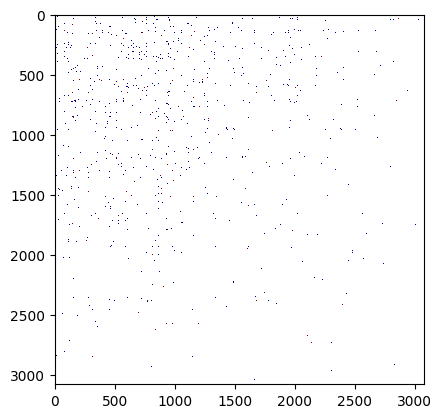

In [9]:
plot_data(train_data)

We see less and less points the more we increase the id value, especially on the y axis. We can assume that users that joined first on the platform have lower ids.

What does this mean? This not only shows that users that have been longer on the platform have swiped more (because of more time to vote on other people), but also shows that users that are very new in the platform **are not shown to other users as much.** Let's look into it a bit closer.

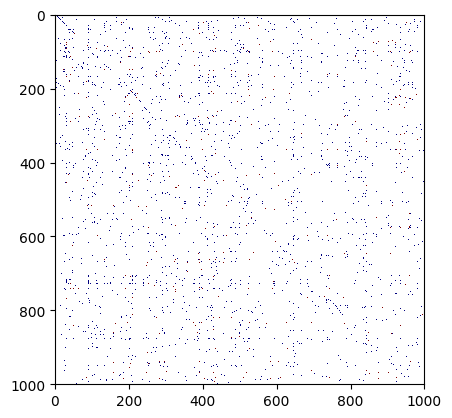

In [10]:
plot_data(train_data, 0, 1000)

This data is fairly dense, with a slight blue line along the diagonal, meaning that some of the users had to vote themselves at one point when using the application.

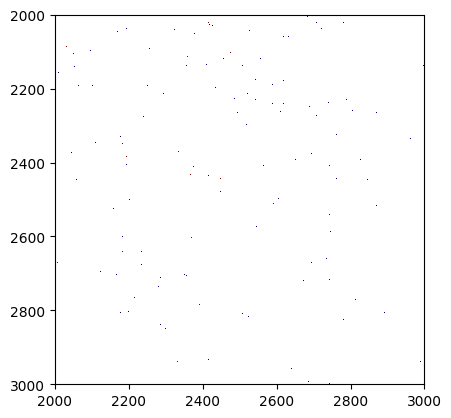

In [11]:
plot_data(train_data, 2000, 3000)

This data is so sparse! Like we speculated, users with higher ids(that joined the application later) have much less votes and also less activity due to less time. It's important we keep this in mind for later when doing our recommender algorithms.

Another thing that we could take into account is that some users might have a higher ratio of likes than others (they are more likeable), and vice versa: some users offer likes much more "care free" (they are generous). Let's plot something that might tell us about how users behave: the likes to dislikes ratio voted by every user.

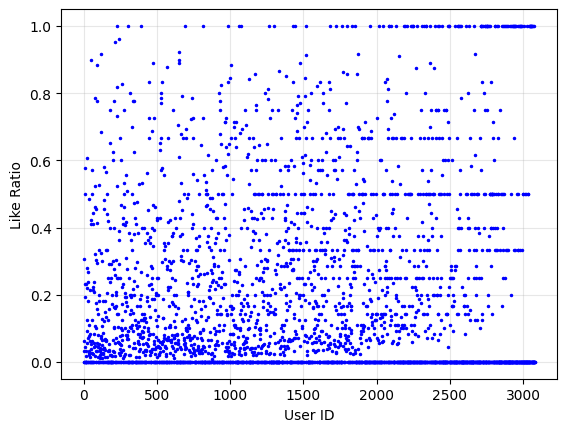

In [12]:
def plot_user_ratios(data, begin_id=-1, end_id=-1):
    if begin_id == -1: begin_id = 0
    if end_id == -1: end_id = data.shape[0]
    user_subset = data[begin_id:end_id, begin_id:end_id]
    
    ratios = np.nanmean(user_subset, axis=1)
        
    user_ids = np.arange(begin_id, end_id)

    plt.plot(user_ids, ratios, 'b.', markersize=3)
    
    plt.xlabel('User ID')
    plt.ylabel('Like Ratio')
    plt.grid(True, alpha=0.3)
    
    plt.pause(0.1)

# Usage
plot_user_ratios(train_data)

As we can see, there are many users that dislike everything, but also a lot that like everyone they are matched with. We can also observe that there are some that have an even distribution between the 2 of them, at the 0.5 mark.

## WebLab solutions

In [13]:
# Solution: NMF routine (for unit test on weblab)

def nmf(X, n_components: int, max_iter: int=1000, tol: float=1e-3):
  """
  Decomposes the original sparse matrix X into two matrices W and H. 
  """

  # Step 1
  X = np.array(X)                                       # X is m x n
  W = np.random.rand(X.shape[0], n_components)          # W is m x p
  H = np.random.rand(n_components, X.shape[1])          # H is p x n

  eps = 1e-9 
  e_old = np.sum(((X - W @ H) ** 2))

  # Step 2
  for i in range(max_iter):
   
    W *= ((X @ H.T) / (W @ H @ H.T + eps))
    H *= ((W.T @ X) / (W.T @ W @ H + eps))      

    # Step 3
    e_new = np.sum(((X - W @ H) ** 2))

    # Step 4
    if abs(e_old - e_new) / (e_old + eps) < tol:
      break
    e_old = e_new

  return W, H

In [14]:
# Solution: Min-hashing routine (for unit test on weblab)

class HashFunction:
    """
    This HashFunction class can be used to create an unique hash given an alpha and beta.
    """
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta

    def hashf(self, x, n):
        """
        Returns a hash given integers x and n.
        :param x: The value to be hashed
        :param n: The number of unique ids of all sets
        :return: The hashed value x given alpha and beta
        """
        
        hash_value = 0
        hash_value =  (self.alpha * x + self.beta) % n
        return hash_value

def compute_signature(hashes: list[HashFunction], ids: list[set[int]]):
    """
    This function will calculate the MinHash signature matrix from our sets of ids
    using the list of hash functions (hashes)
    :param hashes: The list of hash functions of arbitrary length
    :param ids: The list of sets of ids
    :return: The MinHash signature matrix for the given sets of ids
    """

    result = np.full((len(hashes), len(ids)), 999999)
    space = set().union(*ids)
    sorted_space = sorted(space)

    print(enumerate(ids))

    val_to_index = {val:idx for idx, val in enumerate(sorted_space)}
    
    # START ANSWER
    for i, current_set in enumerate(ids):
        for x in current_set:
            idx = val_to_index[x]

            for j, h in enumerate(hashes):
                hashed = h.hashf(idx, len(sorted_space))

                if hashed < result[j, i]:
                    result[j, i] = hashed
    # END ANSWER
    
    return result

## NMF-based recommender system

**NMF with NaNs (nmf_nan)**

- A binary mask **M = ~np.isnan(X)** marks observed entries (True) and missing ones (False).
- Missing values are set to 0 for computation, but all updates and the loss are multiplied by **M**, so NaNs do not contribute to the objective.
- Multiplicative update rules are used (element-wise positive updates) to keep W and H non-negative.

In [15]:
# Step 1: NMF routine which can handle NaNs! (for the 'real data' NMF recommender system task)

def nmf_nan(X, n_components: int, max_iter: int=1000, tol: float=1e-3):
    """
    Computes NMF of matrix X which includes 'unknown' NaN values.
    """

    X = np.array(X)

    # Mask: 1 if present, 0 if missing
    M = ~np.isnan(X)

    X = np.nan_to_num(X, nan=0.0)
    W = np.random.rand(X.shape[0], n_components)          
    H = np.random.rand(n_components, X.shape[1])         

    eps = 1e-9
    e_old = np.sum(M * (X - W @ H) ** 2)

    for i in range(max_iter):

        W *= ((M * X) @ H.T) / (((M * (W @ H)) @ H.T) + eps)
        H *= (W.T @ (M * X)) / (W.T @ (M * (W @ H)) + eps)

        e_new = np.sum(M * (X - (W @ H)) ** 2)
        
        if abs(e_old - e_new) / (e_old + eps) < tol:
            break
        e_old = e_new

    return W, H, e_new

Although NaN values are replaced by zeros for computational reasons, they do not affect the optimization because all updates and error terms are multiplied by a binary mask. Hence missing entries do not contribute to the loss and are not treated as negative feedback.

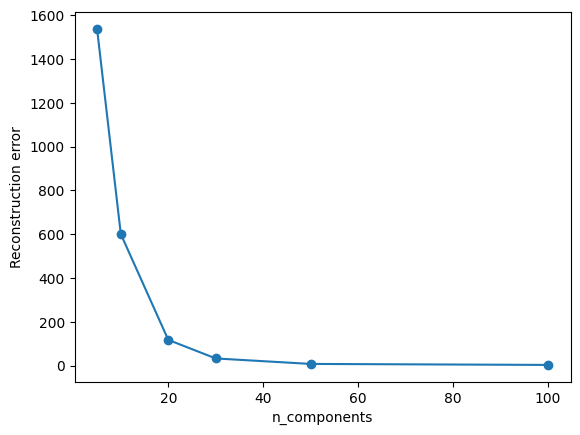

In [16]:
# Step 2: Fit train data

np.random.seed(5)
list_components = [5,10,20,30,50,100]

W_list = []
H_list = []
rec_err_list = []
for n_components in list_components:
    W_i, H_i, rec_err_i = nmf_nan(train_data, n_components, max_iter=200)
    W_list.append(W_i)
    H_list.append(H_i)
    rec_err_list.append(rec_err_i)

plt.plot(list_components, rec_err_list, marker='o')
plt.xlabel("n_components")
plt.ylabel("Reconstruction error")
plt.show()

**Fitting models — procedure and choices**

- We fit **nmf_nan** for a range of **n_components** (model ranks). For each rank we store **W**, **H** and the final reconstruction error.
- The reconstruction error (masked) helps understand model capacity but is not the only selection criterion, we also use validation accuracy to pick the best operating point.

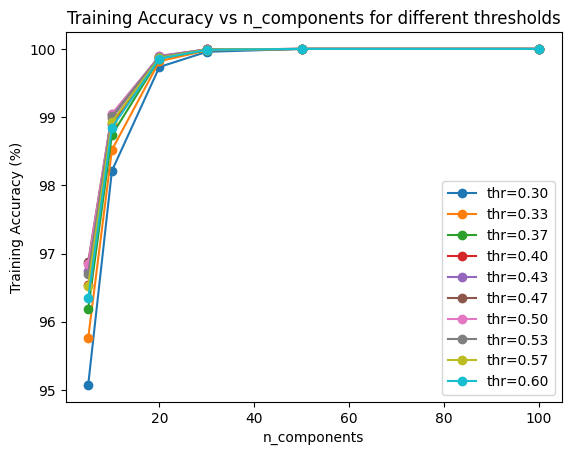

In [17]:
# Step 3: Get training accuracies

list_thr = np.linspace(0.30, 0.60, 10)

M_train = ~np.isnan(train_data)
train_acc = np.zeros((len(list_components), len(list_thr))) 

for c in range(len(list_components)):

    X_rec = W_list[c] @ H_list[c]

    for t, thr in enumerate(list_thr):
        X_pred_train = (X_rec > thr).astype(int)

        correct = (X_pred_train[M_train] == train_data[M_train]).sum()
        total = M_train.sum()

        train_acc[c, t] = correct / total * 100

for t_idx, thr in enumerate(list_thr):
    plt.plot(list_components, train_acc[:, t_idx], marker='o', label=f"thr={thr:.2f}")

plt.xlabel("n_components")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy vs n_components for different thresholds")
plt.legend()
plt.show()

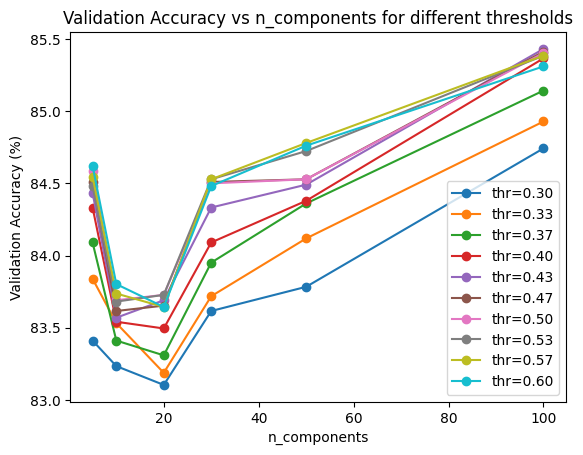

In [18]:
# Step 4: Get validation accuracies

M_val = ~np.isnan(val_data)
val_acc = np.zeros((len(list_components), len(list_thr))) 

for c in range(len(list_components)):

    X_rec = W_list[c] @ H_list[c]

    for t, thr in enumerate(list_thr):
        X_pred_val = (X_rec > thr).astype(int)

        correct = (X_pred_val[M_val] == val_data[M_val]).sum()
        total = M_val.sum()

        val_acc[c, t] = correct / total * 100


for t_idx, thr in enumerate(list_thr):
    plt.plot(list_components, val_acc[:, t_idx], marker='o', label=f"thr={thr:.2f}")

plt.xlabel("n_components")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs n_components for different thresholds")
plt.legend()
plt.show()


**Thresholding, validation and model selection**

- The reconstruction **X_rec = W @ H** produces continuous scores; we convert them to binary predictions by thresholding.
- Accuracies are computed only on observed entries.
- For each **n_components**, we pick the threshold that maximizes validation accuracy. Then we choose the **n_components** with the highest validation accuracy overall.

In [19]:
# Step 5: Get the final test accuracy
# We use the n_components and the threshold we fit on the validation set

best_thr_idx_per_component = val_acc.argmax(axis=1)                 
best_thr_per_component = list_thr[best_thr_idx_per_component] 
best_val_acc_per_component = val_acc.max(axis=1)                    

overall_best_idx = best_val_acc_per_component.argmax()

best_c = list_components[overall_best_idx]                    
best_thr = best_thr_per_component[overall_best_idx]           

M_test = ~np.isnan(test_data)

model_idx = list_components.index(best_c)
X_rec_test = W_list[model_idx] @ H_list[model_idx]

X_pred_test = (X_rec_test > best_thr).astype(int)

correct = (X_pred_test[M_test] == test_data[M_test]).sum()
total = M_test.sum()
test_accuracy = correct / total * 100

print(f"Best n_components: {best_c}")
print(f"Best threshold: {best_thr:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}%")


Best n_components: 100
Best threshold: 0.43
Test accuracy: 84.96%


**Final evaluation on test data**

- After selecting the best **n_components** and its threshold on validation data, we reconstruct the test matrix with the chosen **(W,H)**.
- We threshold the reconstructed scores with the chosen threshold and compute accuracy only on observed test entries (mask **M_test**).
- The test accuracy reflects how well the learned latent factors generalize to unseen entries.

## Distance-based recommender system

First and foremost, we want to create some functions that will make everything easier for us. We already have the compute_signature method, so now let's make the methods for creating the ids of the 1's in the rows and columns for every user, and for creating a set numbe of random hash functions.

In [20]:
import random

def create_hash_functions(n):
    hashes = []
    for i in range(0, n):
        hashes.append(HashFunction(random.randint(1, n), random.randint(1, n * 10)))

    return hashes

In [21]:
def create_ids(data, axis = 0):
    ids = []

    if axis == 0:
        for row in data:
            ids.append(set(np.where(row == 1)[0]))
    else:
        for i in range(data.shape[1]):
            ids.append(set(np.where(data[:, i] == 1)[0]))
    
    return ids

Now, we want to get the nearest neighbours for every user, based on the signature. The nearest neighbours are calculated based on how similar 2 hashes are, so let's do exactly that and get the top k results.

In [22]:
def get_nearest_neighbours(signatures, k = 100):
    n_hashes, n_items = signatures.shape

    nearest_neighbours = []
    for i in range(n_items):
        matches = np.sum(signatures == signatures[:, i].reshape(-1, 1), axis=0) / n_hashes
        
        nearest_neighbours.append(np.argsort(matches)[-k:-1])
    
    return nearest_neighbours

In order to see if our hashes are working well, we can compare the hash similarity to the actual jaccard similarity.

In [23]:
target_user = 1

hashes = create_hash_functions(100)
row_ids = create_ids(train_data, axis = 0)
row_signatures = compute_signature(hashes, row_ids)

row_neighbours = get_nearest_neighbours(row_signatures, 5)

best_match = row_neighbours[target_user][1]
est_sim = np.mean(row_signatures[:, target_user] == row_signatures[:, best_match])

shared_items = len(row_ids[target_user].intersection(row_ids[best_match]))
total_items = len(row_ids[target_user].union(row_ids[best_match]))
actual_jaccard = shared_items / total_items if total_items > 0 else 0

print(f"Target User: {target_user}")
print(f"Recommended Neighbor: {best_match}")
print(f"Min-Hash Estimated Similarity: {est_sim:.4f}")
print(f"Actual Jaccard Similarity:     {actual_jaccard:.4f}")
print(f"Shared Likes (Intersection):   {shared_items}")

Target User: 1
Recommended Neighbor: 876
Min-Hash Estimated Similarity: 0.2600
Actual Jaccard Similarity:     0.2000
Shared Likes (Intersection):   1


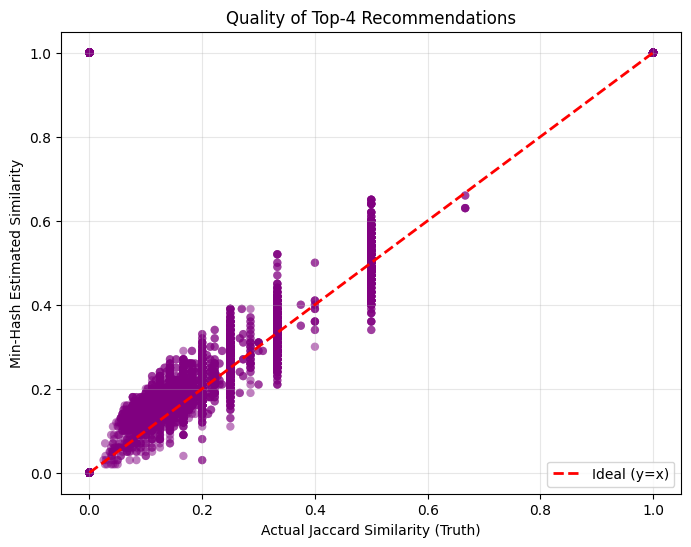

In [24]:
def evaluate_nearest_neighbors_method(train_data, signatures, neighbors_list):
    actual_scores = []
    estimated_scores = []

    for user_id, neighbors in enumerate(neighbors_list):
        user_set = set(np.where(train_data[user_id] == 1)[0])
        user_sig = signatures[:, user_id]
        
        for neighbor_id in neighbors:
            neighbor_set = set(np.where(train_data[neighbor_id] == 1)[0])
            
            intersection = len(user_set.intersection(neighbor_set))
            union = len(user_set.union(neighbor_set))
            actual_sim = intersection / union if union > 0 else 0
            
            neighbor_sig = signatures[:, neighbor_id]
            est_sim = np.mean(user_sig == neighbor_sig)
            
            actual_scores.append(actual_sim)
            estimated_scores.append(est_sim)

    plt.figure(figsize=(8, 6))
    plt.scatter(actual_scores, estimated_scores, alpha=0.5, c='purple', edgecolors='none')
    plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Ideal (y=x)')
    plt.xlabel('Actual Jaccard Similarity (Truth)')
    plt.ylabel('Min-Hash Estimated Similarity')
    plt.title(f'Quality of Top-{len(neighbors)} Recommendations')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

my_neighbors = get_nearest_neighbours(row_signatures, k=5)

evaluate_nearest_neighbors_method(train_data, row_signatures, my_neighbors)

They are very close! This is perfect, and we can't assume we can get very close as our data is very sparse. Let's play with the amount of hash functions we create.

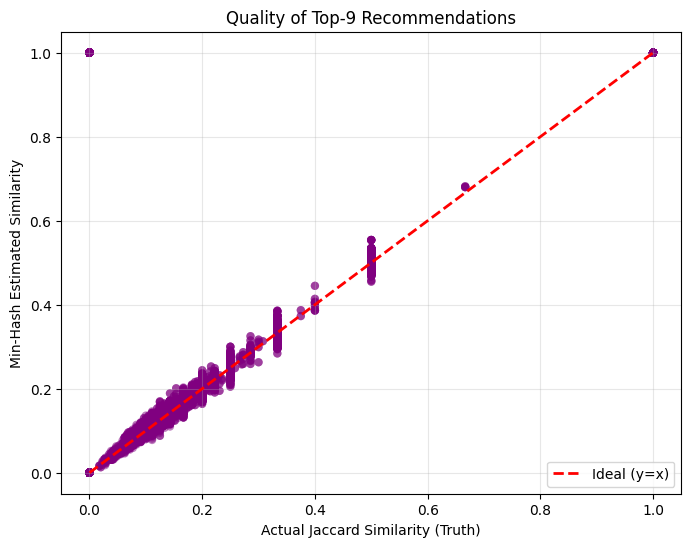

In [25]:
def plot_sim_everything(data, n_hashes, k, axis = 0):
    ids = create_ids(data, axis)
    hashes = create_hash_functions(n_hashes)

    signatures = compute_signature(hashes, ids)
    my_neighbors = get_nearest_neighbours(signatures, k)

    evaluate_nearest_neighbors_method(train_data, signatures, my_neighbors)

plot_sim_everything(train_data, 1000, 10)

Let's also look at how it does for the columns.

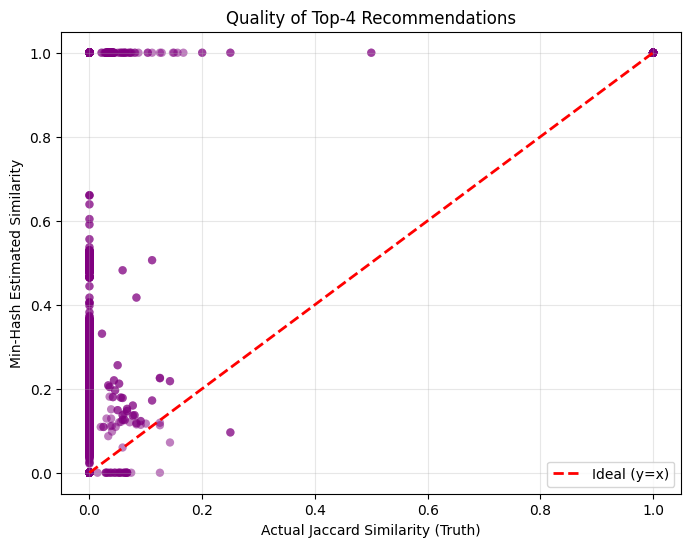

In [26]:
plot_sim_everything(train_data, 1000, 5, axis = 1)

This connects with what we saw in the familiarity section: a lot of users have no likes, so it's difficult to see recommendations for them!

In [29]:
# Aggregate the user-user and item-item nearest neighbor information to estimate recommendations
def get_recommendations(user_id, row_neighbours, col_neighbours, row_ids, k=5):

    seen_items = row_ids[user_id]
    
    votes = {}

    for neighbor_id in row_neighbours[user_id]:
        for item in row_ids[neighbor_id]:
            if item not in seen_items:
                votes[item] = votes.get(item, 0) + 1

    for liked_item in seen_items:
        if liked_item < len(col_neighbours):
            for similar_item in col_neighbours[liked_item]:
                if similar_item not in seen_items:
                    votes[similar_item] = votes.get(similar_item, 0) + 1

    sorted_candidates = sorted(votes.items(), key=lambda x: x[1], reverse=True)
    
    return [item.item() for item, count in sorted_candidates[:k]]

# selected settings:
n_hashes = 100
n_neighbours = 10

hashes = create_hash_functions(n_hashes)

row_ids = create_ids(train_data, axis = 0)
column_ids = create_ids(train_data, axis = 1)
row_signatures = compute_signature(hashes, row_ids)
column_signatures = compute_signature(hashes, column_ids)
row_neighbours = get_nearest_neighbours(row_signatures)
col_neighbours = get_nearest_neighbours(column_signatures)

recs = get_recommendations(1, row_neighbours, col_neighbours, row_ids, n_neighbours)
print(f"Top 5 items: {recs}")

Top 5 items: [950, 593, 2135, 1887, 582, 909, 1683, 1759, 397, 830]


In [36]:
def get_recommendations_weighted(user_id, row_neighbours, col_neighbours, row_ids, 
                                 row_signatures, col_signatures, k=5):

    seen_items = row_ids[user_id]
    votes = {}

    # --- Weight user-user neighbors by signature similarity ---
    for neighbor_id in row_neighbours[user_id]:
        sim = jaccard_similarity(row_signatures[user_id], row_signatures[neighbor_id])
        for item in row_ids[neighbor_id]:
            if item not in seen_items:
                votes[item] = votes.get(item, 0) + sim

    # --- Weight item-item neighbors by signature similarity ---
    for liked_item in seen_items:
        if liked_item < len(col_neighbours):
            for similar_item in col_neighbours[liked_item]:
                sim = jaccard_similarity(col_signatures[liked_item], col_signatures[similar_item])
                if similar_item not in seen_items:
                    votes[similar_item] = votes.get(similar_item, 0) + sim

    sorted_candidates = sorted(votes.items(), key=lambda x: x[1], reverse=True)
    return [item for item, score in sorted_candidates[:k]]


def jaccard_similarity(sig1, sig2):
    return np.mean(sig1 == sig2)


These are the 5 recommendations we get for user 1!! We will see in the following steps whether we did well.

In [38]:
def cross_validate_recommender(train_data, val_data, row_ids, hash_counts=[20, 50], k_values=[5, 10]):
    val_data = val_data.astype(float)
    users_with_val_data = []
    for u in range(val_data.shape[0]):
        if np.any(np.nan_to_num(val_data[u]) == 1):
            users_with_val_data.append(u)
    
    col_ids = []
    for i in range(train_data.shape[1]):
        col_set = set(np.where(train_data[:, i] == 1)[0])
        col_ids.append(col_set)

    for n_hashes in hash_counts:
        hashes = create_hash_functions(n_hashes)
        row_signatures = compute_signature(hashes, row_ids)
        col_signatures = compute_signature(hashes, col_ids)
        
        for k in k_values:
            row_neighbors = get_nearest_neighbours(row_signatures, k)
            col_neighbors = get_nearest_neighbours(col_signatures, k)
            
            total_hits = 0
            total_valid_recs = 0
            
            for user in users_with_val_data:
                # recs = get_recommendations_weighted(user, row_neighbours, col_neighbours, row_ids, row_signatures, col_signatures, k=k)
                recs = get_recommendations(user, row_neighbors, col_neighbors, row_ids, k=k)
                
                for item_id in recs:
                    actual_val = val_data[user, item_id]
                    
                    if np.isnan(actual_val):
                        continue
                    
                    total_valid_recs += 1
                    
                    if actual_val == 1:
                        total_hits += 1
    
            precision = total_hits / total_valid_recs if total_valid_recs > 0 else 0
            
            print(f"{n_hashes:<10} | {k:<10} | {precision:.4f}")

cross_validate_recommender(train_data, val_data, row_ids)

20         | 5          | 0.6183
20         | 10         | 0.5677
50         | 5          | 0.5656
50         | 10         | 0.5795


As we can see, after running our cross validator, we get the best precision for quite a bunch of hash functions and the most amount of neighbours. Let's try with other numbers as well.

In [35]:
cross_validate_recommender(train_data, val_data, row_ids, hash_counts=[100, 500, 1000])

100        | 5          | 0.5694
100        | 10         | 0.5730
500        | 5          | 0.5694
500        | 10         | 0.5810
1000       | 5          | 0.5528
1000       | 10         | 0.6000


The biggest precision we got was with 500 hash functions and 10 neighbours, so we are going to use that. Even though it's pretty low, it's to be expected with such a cold start and with this binary raw data type of matrix. Also, we removed the nans in the validation set from the counting because it dragged the metric down a lot.

In [41]:
has_likes = np.nansum(test_data == 1, axis=1) > 0
test_users = np.where(has_likes)[0]

total_hits = 0
total_valid_recs = 0

for user in test_users:
    recs = get_recommendations(user, row_neighbours, col_neighbours, row_ids, k=5)
    
    for item_id in recs:
        actual_val = test_data[user, item_id]
        
        if np.isnan(actual_val):
            continue
            
        total_valid_recs += 1
        
        if actual_val == 1:
            total_hits += 1

precision = total_hits / total_valid_recs if total_valid_recs > 0 else 0

print(f"Final Test Accuracy (Precision) [Ignoring NaNs]: {precision:.4f}")
print(f"Total Valid Recommendations: {total_valid_recs}")
print(f"Total Hits: {total_hits}")

Final Test Accuracy (Precision) [Ignoring NaNs]: 0.6525
Total Valid Recommendations: 141
Total Hits: 92


As for the validation set, we eliminated the nans from the test set to calculate the accuracy because it drags it down very much. As we can see, our Distance Based Recommender System has a precision of 68%, so out of 141 total recommendations 96 were correct.